In [ ]:
import stlrom as stl
from stlrom import RandSignalGen

from ipywidgets import interact, interactive, fixed, interact_manual

In [ ]:
v_min=-5
v_max=5
dv_max=1
dt_min=0.1
dt_max=0.2

rand_sg_pwc = RandSignalGen(v_min=v_min, v_max=v_max, dv_max=dv_max, dt_min=dt_min, dt_max=dt_max)
rand_sg_pwl = RandSignalGen(dv_max=dv_max, dt_min=dt_min, dt_max=dt_max, interp='LINEAR')

In [ ]:
specs = """
signal x, y

mu_x := x[t]>0
mu_y := y[t]>0
mu_cmp := x[t] < y[t]-1

phi_pos:= alw[0, 10] x[t]>0
phi_ev := ev[0, 5] x[t]<-4
phi_ev_low_then_high:= ev[0, 5] x[t]<-4 and ev[5,10] (x[t]>4)
phi_alw_low_then_high:= alw[0, 5] x[t]<-4 and alw[5,10] (x[t]>4)
phi_cmp:= alw[0,10] mu_cmp
phi_until := mu_x until[5,10] mu_y

phi:= phi_alw_low_then_high
"""

D = stl.STLDriver()
D.parse_string(specs)


In [36]:
seed_x=0
seed_y=0
def find_sig(phi):
    for seed_x in range(0,100):
        for seed_y in range(0,100):
            x= rand_sg_pwc.set_param(seed=seed_x).get_signal(0,10)
            y= rand_sg_pwc.set_param(seed=seed_y).get_signal(0,10)
            D.set_signals([x,y])    
            rob = D.get_rob(phi)
            #print(f'{seed_x, seed_y}: {rob}')
            if rob>0:
                break
        if rob>0:
            print(f'FOUND: ', f'{seed_x, seed_y}: {rob}')
            break    
    return seed_x, seed_y

def plot_seed(seed_x=0, seed_y=1, phi= 'phi'):
    x= rand_sg_pwc.set_param(seed=seed_x).get_signal(0,10)
    y= rand_sg_pwc.set_param(seed=seed_y).get_signal(0,10)
    D.set_signals([x,y])        
    rob = D.get_rob('phi')
    print(f'rob: {rob}')
    D.plot_rob(phi, 0,10)
    return D.plot_signals()

FOUND:  (2, 1): 0.8529414463533325
rob: -9.0


<Axes: xlabel='Time', ylabel='Value'>

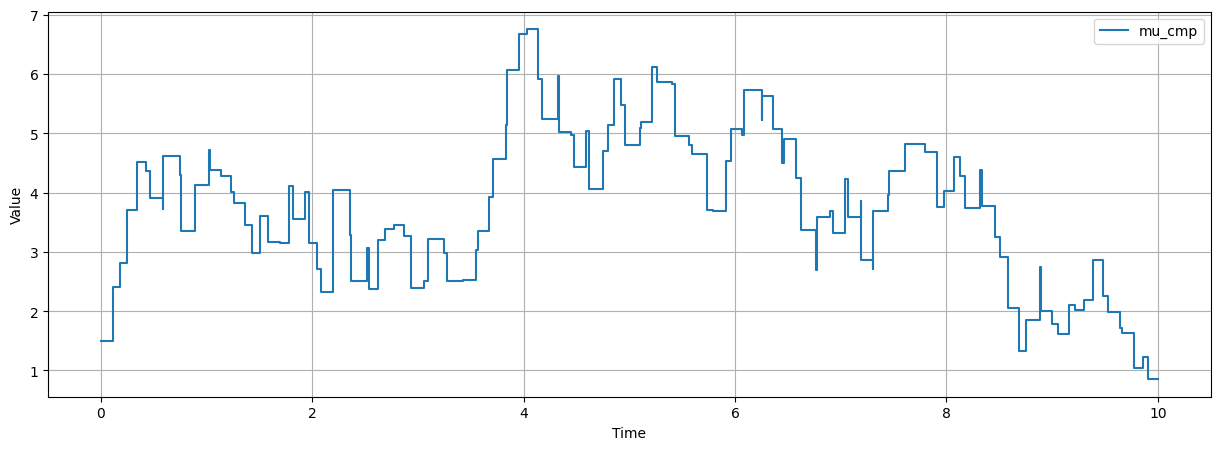

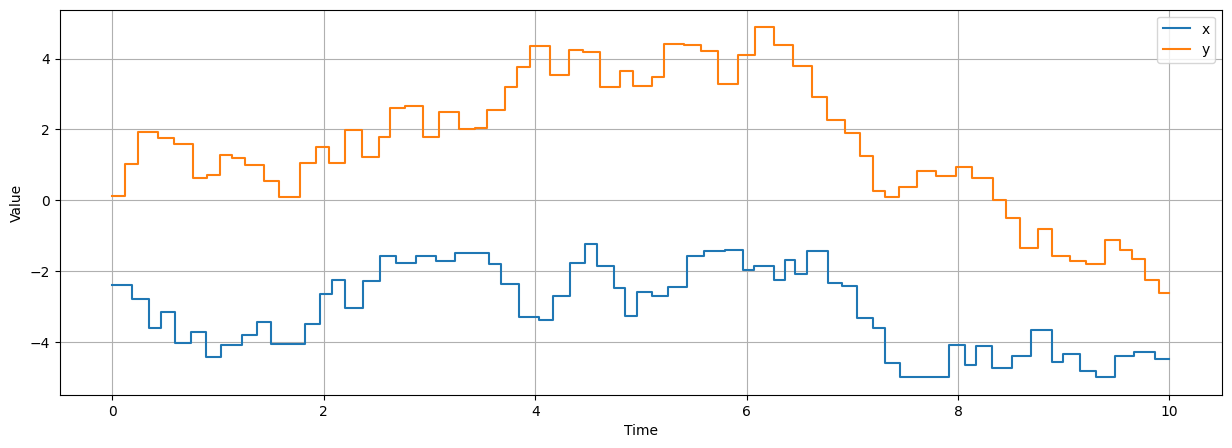

In [37]:
phi = 'phi_cmp'
seed_x, seed_y = find_sig(phi)
plot_seed(seed_x=seed_x, seed_y=seed_y, phi= 'mu_cmp')

In [ ]:
interact(plot_seed, seed_x=(0,100), seed_y=(0,100), phi=['mu_x', 'mu_y','phi_ev' ])

In [ ]:
D.plot_sat('phi',0,10)